In [ ]:
import requests
import geopandas as gpd
import matplotlib.pyplot as plt
from io import BytesIO



In [ ]:
WFS_URL = "https://openmaps.gov.bc.ca/geo/pub/WHSE_LEGAL_ADMIN_BOUNDARIES.DRP_MOF_FIRE_ZONES_SP/ows"

params = {
    "service": "WFS",
    "version": "2.0.0",
    "request": "GetFeature",
    "typeNames": "WHSE_LEGAL_ADMIN_BOUNDARIES.DRP_MOF_FIRE_ZONES_SP",
    "outputFormat": "application/json",
    "CQL_FILTER": "MOF_FIRE_CENTRE_NAME='Cariboo Fire Centre'"
}


# -----------------------------
response = requests.get(WFS_URL, params=params)
response.raise_for_status()


gdf = gpd.read_file(BytesIO(response.content))

print(f"Loaded {len(gdf)} fire zones")
print(gdf[["MOF_FIRE_CENTRE_NAME", "MOF_FIRE_ZONE_NAME"]])

Loaded 4 fire zones
  MOF_FIRE_CENTRE_NAME         MOF_FIRE_ZONE_NAME
0  Cariboo Fire Centre   100 Mile House Fire Zone
1  Cariboo Fire Centre        Chilcotin Fire Zone
2  Cariboo Fire Centre          Quesnel Fire Zone
3  Cariboo Fire Centre  Central Cariboo Fire Zone


In [ ]:
gdf

,id,MOF_FIRE_ZONE_ID,MOF_FIRE_CENTRE_NAME,MOF_FIRE_ZONE_NAME,HEADQUARTERS_CITY_NAME,OBJECTID,SE_ANNO_CAD_DATA,FEATURE_AREA_SQM,FEATURE_LENGTH_M,geometry
0,WHSE_LEGAL_ADMIN_BOUNDARIES.DRP_MOF_FIRE_ZONES...,493,Cariboo Fire Centre,100 Mile House Fire Zone,100 Mile House,1104,None,1.236059e+10,7.452190e+05,"POLYGON ((1365595.79 811388.999, 1365587.148 8..."
1,WHSE_LEGAL_ADMIN_BOUNDARIES.DRP_MOF_FIRE_ZONES...,496,Cariboo Fire Centre,Chilcotin Fire Zone,Williams Lake,1107,None,2.871304e+10,1.146598e+06,"POLYGON ((1176324.025 842019.703, 1176323.53 8..."
2,WHSE_LEGAL_ADMIN_BOUNDARIES.DRP_MOF_FIRE_ZONES...,498,Cariboo Fire Centre,Quesnel Fire Zone,Quesnel,1109,None,2.077233e+10,1.337766e+06,"POLYGON ((1264933.277 942501.98, 1264888.802 9..."
3,WHSE_LEGAL_ADMIN_BOUNDARIES.DRP_MOF_FIRE_ZONES...,510,Cariboo Fire Centre,Central Cariboo Fire Zone,Williams Lake,1121,None,2.063411e+10,1.316524e+06,"POLYGON ((1393202.155 890463.295, 1393201.79 8..."


In [ ]:
gdf = gdf.to_crs(epsg=3005)

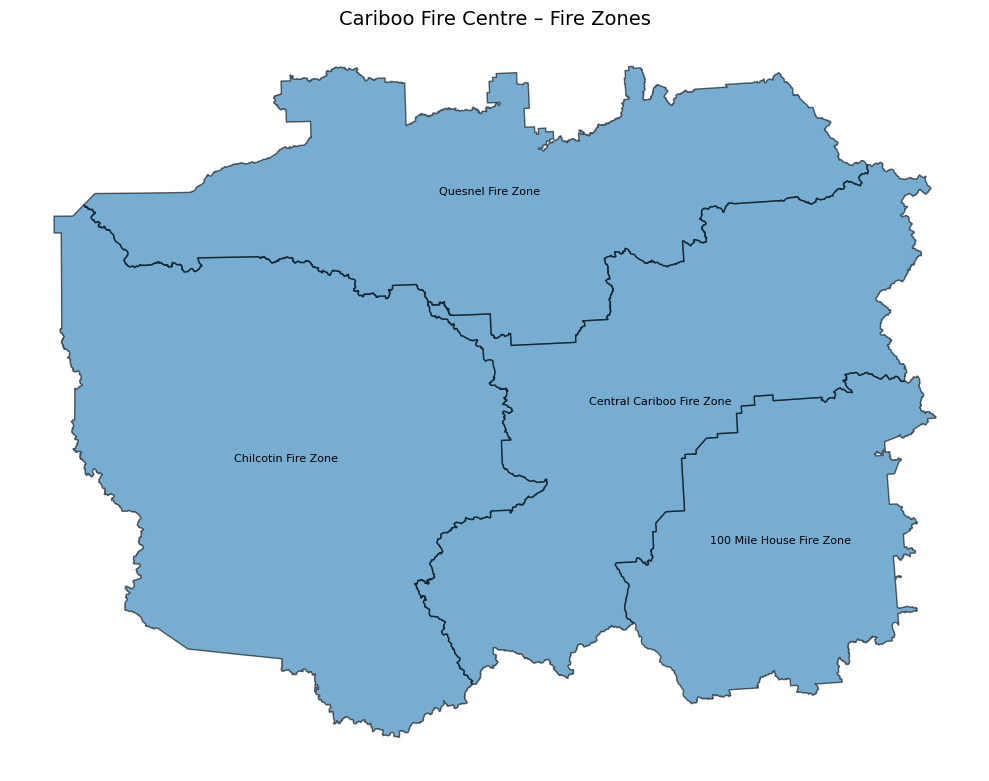

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(
    ax=ax,
    edgecolor="black",
    linewidth=1,
    alpha=0.6
)

# Label fire zones
for idx, row in gdf.iterrows():
    centroid = row.geometry.centroid
    ax.text(
        centroid.x,
        centroid.y,
        row["MOF_FIRE_ZONE_NAME"],
        fontsize=8,
        ha="center"
    )

ax.set_title("Cariboo Fire Centre – Fire Zones", fontsize=14)
ax.set_axis_off()

plt.tight_layout()
plt.show()

HTTPError: 404 Client Error: Not Found for url: https://openmaps.gov.bc.ca/geo/pub/WHSE_LAND_AND_NATURAL_RESOURCE/ows?service=WFS&version=2.0.0&request=GetFeature&typeNames=WHSE_LAND_AND_NATURAL_RESOURCE.PROT_HISTORICAL_FIRE_POINTS_SP&outputFormat=application%2Fjson&CQL_FILTER=FIRE_YEAR+%3E%3D+2000

: 